In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils.utils import printmessage
import glob
import tqdm


In [51]:
final_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A-20241112-111125-0-15000-token_normalise_ver161024_ON0090_m6Afinal/pileup.npz"
with np.load(final_df) as f:
    final_df = {k: v for k, v in f.items()}
final_df = pd.DataFrame(final_df)
print(final_df)

          label_id  pm6a       dom  count_all  count_pos  kl_div_neg  \
0                0   0.0  0.000000          4          0    3.929031   
1                1   0.0  0.000000         36          0   34.809502   
2                2   0.0  0.000000         13          0   11.769886   
3                3   0.0  0.000000          1          0    0.910063   
4                4  -0.0  0.006849          8          0    5.785092   
...            ...   ...       ...        ...        ...         ...   
33284916  33353028   0.0  0.000000         13          0   12.815153   
33284917  33353029   0.0  0.000000         13          0   12.932650   
33284918  33353030   0.0  0.000000         13          0   12.959581   
33284919  33353031   0.0  0.000000         12          0   11.957610   
33284920  33353032   0.0  0.000000         12          0   11.940466   

          kl_div_pos  logsum_1_p_pos  
0           0.000000             0.0  
1           0.000000             0.0  
2           0.0000

In [52]:
label_df = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pileup.filtered.pkl.sorted.pkl"
label_df = pd.read_pickle(label_df)
print(label_df)


             index          nmid    pos         label_id
0                0  NM_001354227      0   NM_001354227:0
1                1     NM_024682      0      NM_024682:0
2                2  NM_001323052      2   NM_001323052:2
3                3  NM_001145155      2   NM_001145155:2
4                4  NM_001244938      2   NM_001244938:2
...            ...           ...    ...              ...
33353028  33353028     NR_002728  82892  NR_002728:82892
33353029  33353029     NR_002728  82895  NR_002728:82895
33353030  33353030     NR_002728  82897  NR_002728:82897
33353031  33353031     NR_002728  82900  NR_002728:82900
33353032  33353032     NR_002728  82902  NR_002728:82902

[33353033 rows x 4 columns]


In [54]:

index_id_dict = dict(zip(label_df["index"], label_df["label_id"]))
final_df["label_id"] = final_df["label_id"].map(index_id_dict)
print(final_df)

                 label_id  pm6a       dom  count_all  count_pos  kl_div_neg  \
0          NM_001354227:0   0.0  0.000000          4          0    3.929031   
1             NM_024682:0   0.0  0.000000         36          0   34.809502   
2          NM_001323052:2   0.0  0.000000         13          0   11.769886   
3          NM_001145155:2   0.0  0.000000          1          0    0.910063   
4          NM_001244938:2  -0.0  0.006849          8          0    5.785092   
...                   ...   ...       ...        ...        ...         ...   
33284916  NR_002728:82892   0.0  0.000000         13          0   12.815153   
33284917  NR_002728:82895   0.0  0.000000         13          0   12.932650   
33284918  NR_002728:82897   0.0  0.000000         13          0   12.959581   
33284919  NR_002728:82900   0.0  0.000000         12          0   11.957610   
33284920  NR_002728:82902   0.0  0.000000         12          0   11.940466   

          kl_div_pos  logsum_1_p_pos  
0           

In [55]:
path = f"/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A-20241112-111125-0-15000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.npz"
np.savez_compressed(path, **{key: final_df[key].values for key in final_df.columns})

In [56]:
## Confrim No NaN in the final_df
print(final_df.isna().sum())

label_id          0
pm6a              0
dom               0
count_all         0
count_pos         0
kl_div_neg        0
kl_div_pos        0
logsum_1_p_pos    0
dtype: int64


In [3]:
data = "/extdata4/baeklab/Hyeonseo/m6A/dataset/ver110724_m6A_exclude_ON0099/score-perfect/val/pos/000016818.npz"
with np.load(data) as f:
    data = {k: v for k, v in f.items()}
print(data)

{'segment_len_arr': array([[ 4,  1,  1, ...,  4,  8,  4],
       [ 4,  2,  2, ...,  8,  2,  6],
       [ 4,  4,  4, ...,  2,  2,  4],
       ...,
       [ 1,  1,  4, ...,  4,  2,  4],
       [ 2,  4,  4, ...,  6,  6,  2],
       [ 6,  8, 90, ...,  4,  6,  6]], dtype=uint8), 'signal_token': array([[-0.5201327 , -0.18832392, -0.43045467, ...,  0.        ,
         0.        ,  0.        ],
       [-0.66245943, -0.66245943, -0.779661  , ...,  0.        ,
         0.        ,  0.        ],
       [ 2.526194  ,  0.41718027, -0.19915254, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.9870747 , -0.59797585, -0.21997318, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.2131214 ,  0.11580569,  0.35098532, ...,  0.        ,
         0.        ,  0.        ],
       [ 1.6570075 ,  1.5749954 ,  1.4383087 , ...,  0.        ,
         0.        ,  0.        ]], dtype=float32), 'kmer_token': array([[65, 67, 85, ..., 65, 65, 65],
       [65, 71, 85, ..., 71,

In [14]:
print(len(data["signal_token"][0]))
print(len(data["segment_len_arr"][0]))

1224
17


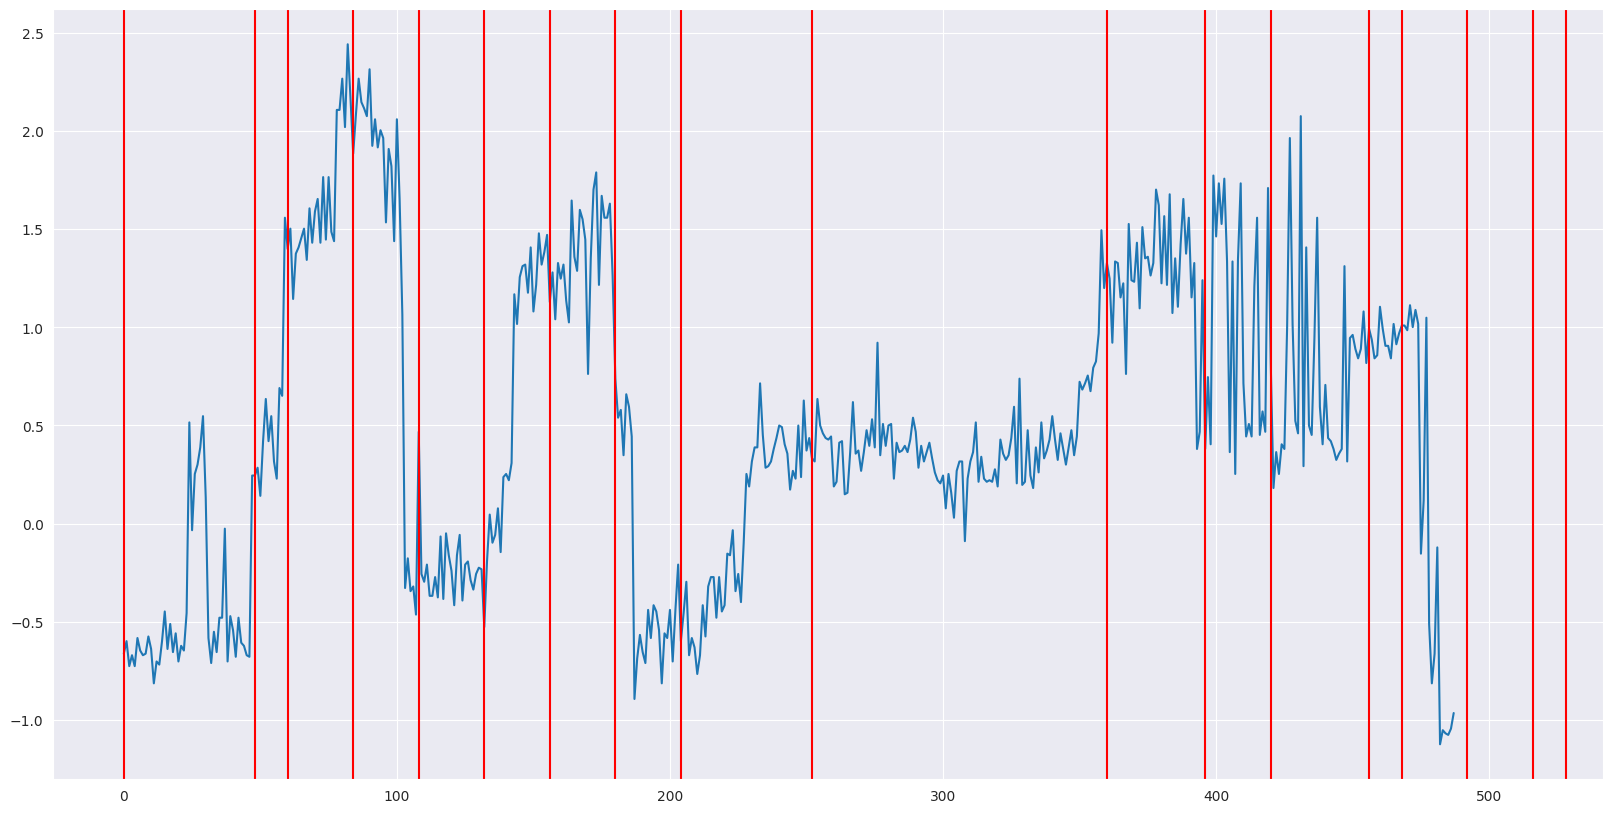

In [28]:
## Visualise the data
k = 5
plt.figure(figsize=(20, 10))
plt.plot(data["signal_token"][k][12:500])
## Vline at the segment_len_arr 
for i in np.concatenate([[0],np.cumsum(data["segment_len_arr"][k]*6).astype(int)]):
    plt.axvline(i, color="r")
plt.show()

In [44]:
from sklearn.metrics import precision_recall_curve

def plot_pr_curve_2(df_dict, colour_list, total_dict):
    plt.rcParams.update({'font.size': 24})
    fig, ax = plt.subplots(1,1,figsize=(20,20))
    for i, (name, df) in enumerate(df_dict.items()):
        x = df["score"].to_numpy()
        y = df["correct"].to_numpy()
        total = total_dict[name]
        x = np.concatenate([x, np.zeros(total - np.sum(y), dtype=float)])
        y = np.concatenate([y, np.ones(total - np.sum(y), dtype=int)], dtype=int)
        precision, recall, _ = precision_recall_curve(y, x)
        ax.plot(recall[1:], precision[1:], label=f"{name}", color=colour_list[i], linewidth=5)

        ## Plot the point with the highest precision
        print(precision)
        max_precision = np.max(precision[:-1])
        max_precision_idx = np.argmax(precision[:-1])
        max_precision_recall = recall[:-1][max_precision_idx]
        text = f"{name}: Max Precision = {max_precision:.3f}, Recall = {max_precision_recall:.3f}"
        ax.axvline(x=max_precision_recall, color="grey", linestyle="--", linewidth=2)
        ax.axhline(y=max_precision, color="grey", linestyle="--", linewidth=2)
        ax.text(max_precision_recall, max_precision, text, fontsize=20, color="grey")


    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.legend()
    plt.show()
    return None


In [39]:
bb87_path = "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_IVT/ON0095/ON0095/result/block/pentamer_block.pkl_downsampled.pkl_with_align_pairs_correct.pkl"

bb87_df = pd.read_pickle(bb87_path)

df_dict = {"87BB: 21CB x 3 + 6SP x 4": bb87_df,
           }
total_dict = {"87BB: 21CB x 3 + 6SP x 4": 15*100000,
              }
colour_list = ["royalblue", "tomato", "forestgreen", "orchid", "darkgoldenrod", "turquoise"]

[0.95916208 0.95352745 0.95612908 0.95903235 0.96091269 0.9633215
 0.96507322 0.97220811 0.97325913 0.97429593 0.98159626 0.9826007
 0.98279447 0.99714664 0.99742447 1.        ]


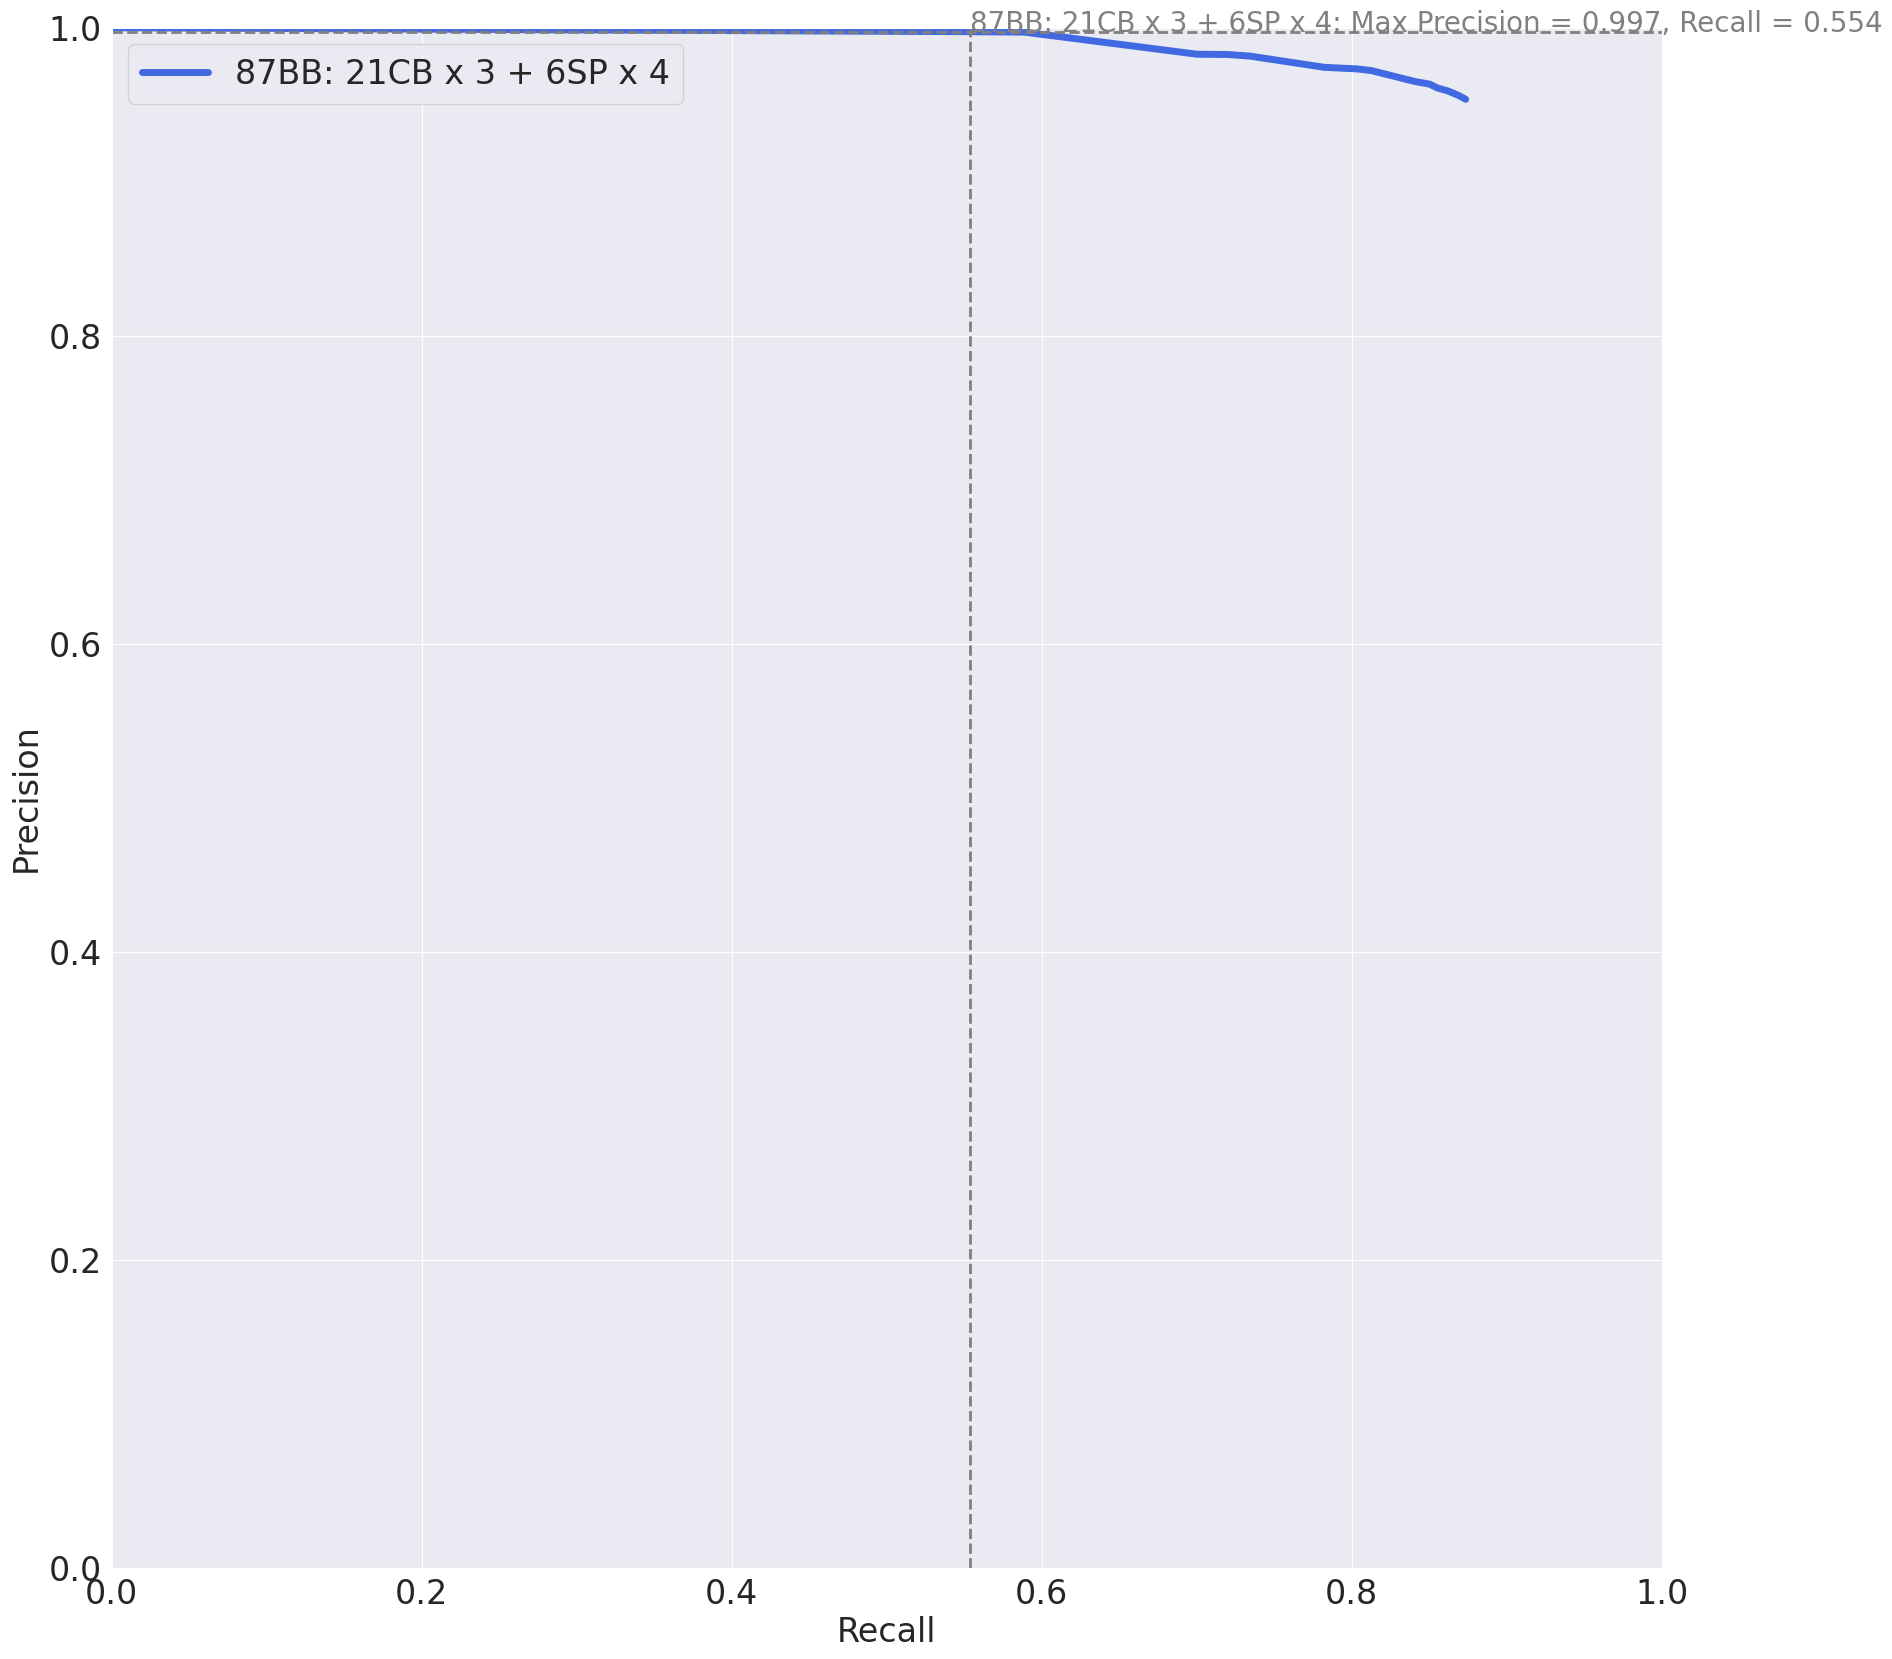

In [45]:
plot_pr_curve_2(df_dict, colour_list, total_dict)

In [46]:
with np.load("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/result/block_070/token_normalise_ver111924_postprocess_d200/77-13-24-0.npz") as f:
    data = {k: v for k, v in f.items()}

print(data)

{'segment_len_arr': array([[ 6,  6,  6, ...,  4,  4, 10],
       [ 6,  6,  6, ...,  4, 10,  4],
       [ 3,  8,  5, ...,  4,  4,  4],
       ...,
       [ 2,  4,  2, ...,  2,  4,  2],
       [ 2,  2,  4, ...,  4,  3,  3],
       [ 2,  4,  4, ...,  3,  3,  4]], dtype=uint8), 'signal_token': array([[ 0.4209764 , -0.11502245,  1.0294075 , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.0298421 ,  0.39200348,  0.1891931 , ...,  0.        ,
         0.        ,  0.        ],
       [ 1.5581632 ,  0.9424888 ,  1.2611908 , ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 1.9186096 ,  1.0582466 ,  1.0840575 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.73130864, -0.7571195 , -0.7141014 , ...,  0.        ,
         0.        ,  0.        ],
       [-0.2581089 , -0.3613525 , -0.38716337, ...,  0.        ,
         0.        ,  0.        ]], dtype=float32), 'kmer_token': array([[65, 84, 65, ..., 67, 65, 71],
       [84, 65, 71, ..., 65,